In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [6]:
# Load Iris dataset using sklearn.
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

In [7]:
# Selecting only two features for visualization
X = df[['sepal length (cm)', 'sepal width (cm)']].values

In [8]:
#Standardize the data
Scaler = StandardScaler()
X_scaled = Scaler.fit_transform(X)

In [9]:
Kmeans = KMeans(n_clusters=5, init='k-means++',random_state=42)
y_kmeans = Kmeans.fit_predict(X_scaled)

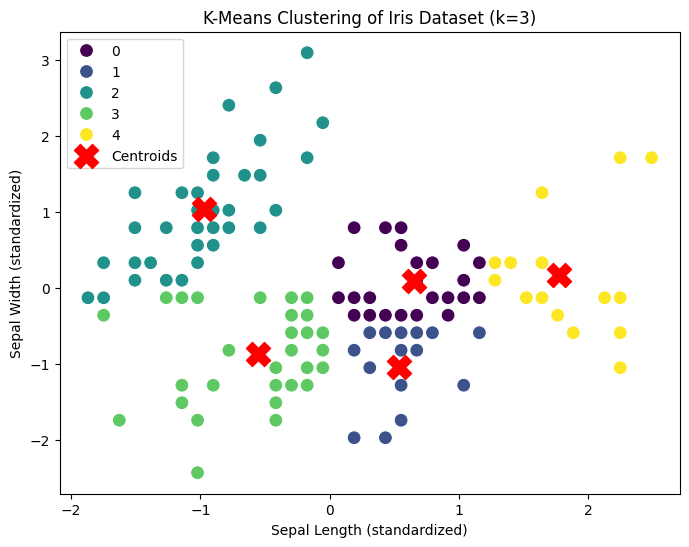

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,0],y=X_scaled[:,1],hue=y_kmeans,palette='viridis',s=100)
plt.scatter(Kmeans.cluster_centers_[:, 0],Kmeans.cluster_centers_[:, 1],s=300,c='red',marker='X',label='Centroids')
plt.xlabel('Sepal Length (standardized)')
plt.ylabel('Sepal Width (standardized)')
plt.title('K-Means Clustering of Iris Dataset (k=3)')
plt.legend()
plt.show()

# Exercise 2:

In [11]:
wcss = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

In [12]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from kneed import KneeLocator
knee_locator = KneeLocator(k_values, wcss, curve='convex', direction='decreasing')
optimal_k = knee_locator.elbow

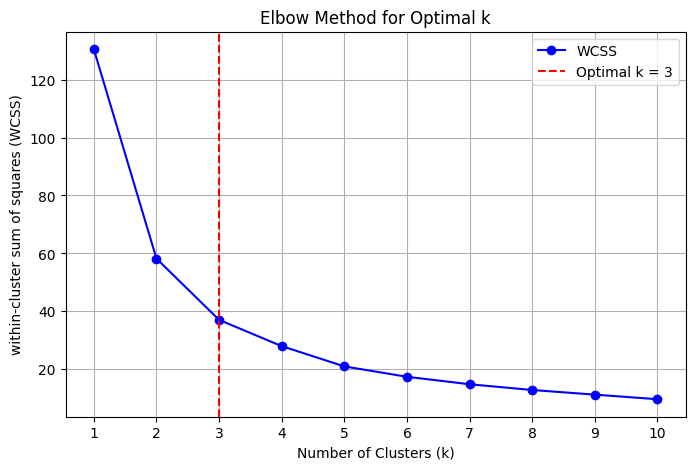

In [24]:
plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o',linestyle='-',color='b',label='WCSS')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel("within-cluster sum of squares (WCSS)")
plt.title('Elbow Method for Optimal k')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

# Exercise 3: Implement PCA on a given matrix

In [15]:
import numpy as np

In [ ]:
# step1: create a sample dataset
X=np.array([
    [2,3,4],
    [3,5,6],
    [5,8,9],
    [6,9,11],
    [7,10,13]
])

In [20]:
# step2: compute mean value for each column
mean_X = np.mean(X, axis=0)
print(mean_X)

[4.6 7.  8.6]


In [21]:
# step3: center the data
X_centered=X - mean_X
print(X_centered)

[[-2.6 -4.  -4.6]
 [-1.6 -2.  -2.6]
 [ 0.4  1.   0.4]
 [ 1.4  2.   2.4]
 [ 2.4  3.   4.4]]


In [23]:
# step4: compute the covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)
print(cov_matrix)

[[ 4.3   6.    7.55]
 [ 6.    8.5  10.5 ]
 [ 7.55 10.5  13.3 ]]


In [ ]:
# Step5: compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print(eigenvalues)

[2.59637803e+01 5.52557327e-03 1.30694106e-01]
